In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import Planetoid

c:\Users\sumit\OneDrive\Desktop\Code_PlayGround\End To End DL Project\PaperNet-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Planetoid(root = "../artifacts/data", name = "cora")

In [4]:
data = dataset[0]
pd.Series(data.y.numpy()).value_counts().sort_index()

0    351
1    217
2    418
3    818
4    426
5    298
6    180
Name: count, dtype: int64

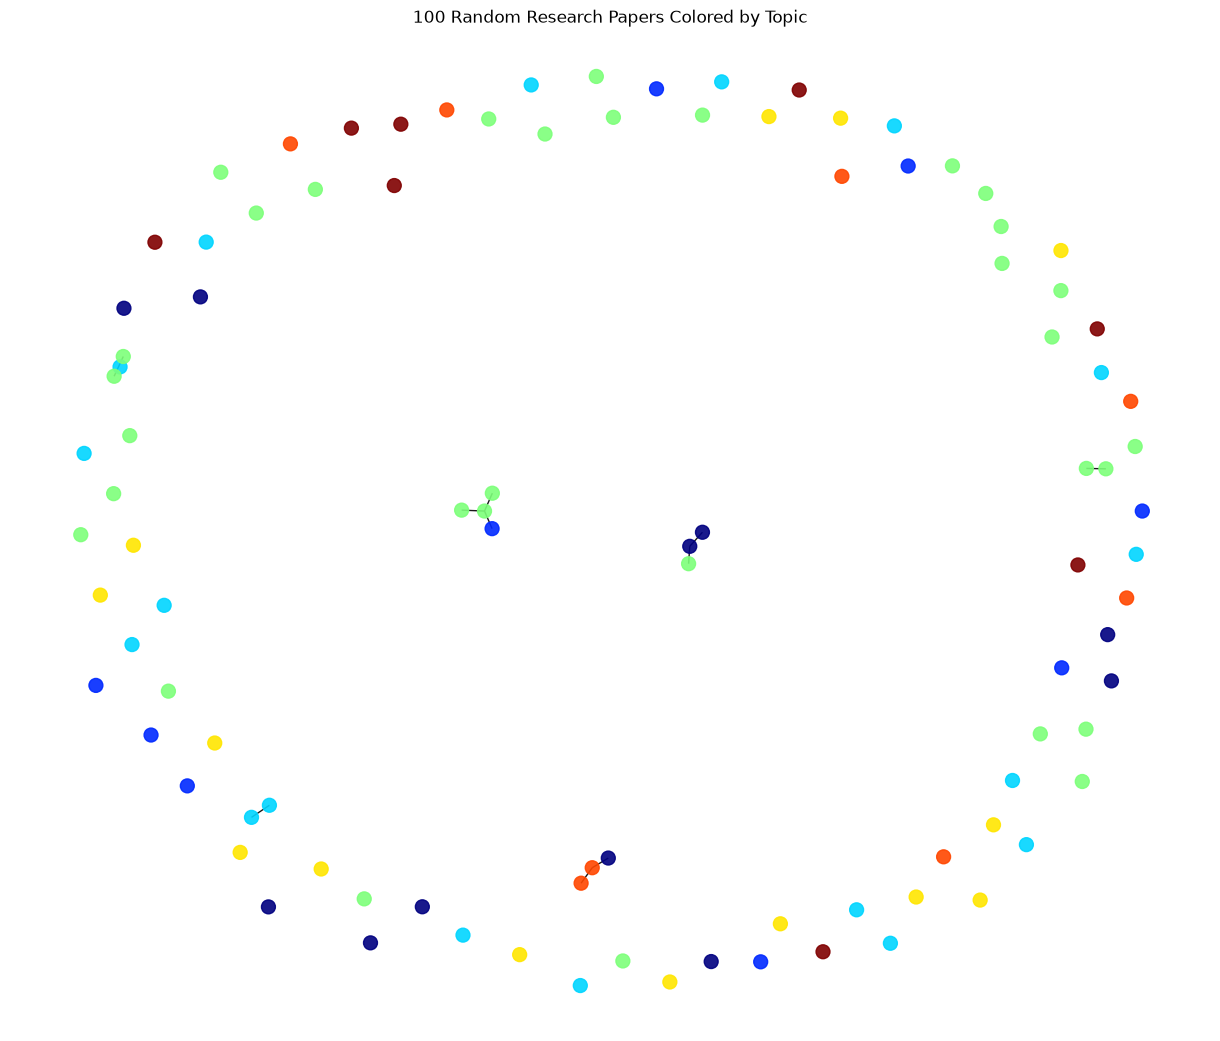

In [5]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

In [6]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GATv2Conv, JumpingKnowledge
from torch_geometric.utils import degree, dropout_edge

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [8]:
print(data)
print()
print(f"Nodes       : {data.num_nodes}")
print(f"Edges       : {data.num_edges}")
print(f"Features    : {data.num_node_features}")
print(f"Classes     : {dataset.num_classes}")
print(f"Train nodes : {data.train_mask.sum().item()}")
print(f"Val nodes   : {data.val_mask.sum().item()}")
print(f"Test nodes  : {data.test_mask.sum().item()}")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

Nodes       : 2708
Edges       : 10556
Features    : 1433
Classes     : 7
Train nodes : 140
Val nodes   : 500
Test nodes  : 1000


In [9]:
data = data.to(device)

print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [10]:
row, col = data.edge_index

node_degree = degree(
    row,
    num_nodes=data.num_nodes
)

print(f"Average degree : {node_degree.mean().item():.2f}")
print(f"Min degree     : {node_degree.min().item():.0f}")
print(f"Max degree     : {node_degree.max().item():.0f}")

Average degree : 3.90
Min degree     : 1
Max degree     : 168


In [11]:
INPUT_DIM = data.num_node_features
HIDDEN_DIM = 128
NUM_CLASSES = dataset.num_classes

NUM_LAYERS = 3
HEADS = 4

DROPOUT = 0.35
ATTENTION_DROPOUT = 0.20

print("Input dimension :", INPUT_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Classes         :", NUM_CLASSES)
print("GAT layers      :", NUM_LAYERS)
print("Attention heads :", HEADS)

Input dimension : 1433
Hidden dimension: 128
Classes         : 7
GAT layers      : 3
Attention heads : 4


In [12]:
class GATv2Block(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        heads=4,
        dropout=0.35,
        attention_dropout=0.2
    ):
        super().__init__()

        self.conv = GATv2Conv(
            in_channels=in_channels,
            out_channels=out_channels // heads,
            heads=heads,
            concat=True,
            dropout=attention_dropout,
            add_self_loops=True
        )

        self.norm = nn.LayerNorm(out_channels)

        self.residual = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Linear(in_channels, out_channels, bias=False)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):

        residual = self.residual(x)

        x = self.conv(x, edge_index)

        x = self.norm(x)

        x = F.gelu(x)

        x = self.dropout(x)

        x = x + residual

        return x

In [13]:
class AdvancedCoraGAT(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_classes,
        num_layers=3,
        heads=4,
        dropout=0.35,
        attention_dropout=0.20
    ):
        super().__init__()

        # ------------------------------------------------
        # Feature projection
        # ------------------------------------------------
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # ------------------------------------------------
        # GATv2 layers
        # ------------------------------------------------
        self.gnn_layers = nn.ModuleList()

        for _ in range(num_layers):
            self.gnn_layers.append(
                GATv2Block(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    heads=heads,
                    dropout=dropout,
                    attention_dropout=attention_dropout
                )
            )

        # ------------------------------------------------
        # Jumping Knowledge
        # ------------------------------------------------
        self.jk = JumpingKnowledge(
            mode="cat"
        )

        jk_dim = hidden_dim * num_layers

        # ------------------------------------------------
        # Classification head
        # ------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(jk_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.40),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x, edge_index):

        # Initial feature projection
        x = self.input_projection(x)

        representations = []

        # GNN layers
        for layer in self.gnn_layers:

            x = layer(
                x,
                edge_index
            )

            representations.append(x)

        # Jumping Knowledge
        x = self.jk(representations)

        # Classification
        logits = self.classifier(x)

        return logits

In [14]:
model = AdvancedCoraGAT(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    num_layers=NUM_LAYERS,
    heads=HEADS,
    dropout=DROPOUT,
    attention_dropout=ATTENTION_DROPOUT
).to(device)

print(model)

AdvancedCoraGAT(
  (input_projection): Sequential(
    (0): Linear(in_features=1433, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.35, inplace=False)
  )
  (gnn_layers): ModuleList(
    (0-2): 3 x GATv2Block(
      (conv): GATv2Conv(128, 32, heads=4)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (residual): Identity()
      (dropout): Dropout(p=0.35, inplace=False)
    )
  )
  (jk): JumpingKnowledge(cat)
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.25, inplace=False)
    (7): Linear(in_features=64, out_features=7, bias=True)
  )
)


In [15]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 342,663


In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.003,
    weight_decay=5e-4
)


In [17]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=15,
    min_lr=1e-5
)

In [18]:
def train_one_epoch():

    model.train()

    optimizer.zero_grad()

    # Randomly remove a small fraction of edges
    train_edge_index, _ = dropout_edge(
        data.edge_index,
        p=0.10,
        force_undirected=False
    )

    logits = model(
        data.x,
        train_edge_index
    )

    loss = F.cross_entropy(
        logits[data.train_mask],
        data.y[data.train_mask],
        label_smoothing=0.05
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=2.0
    )

    optimizer.step()

    return loss.item()

In [19]:
@torch.no_grad()
def evaluate(mask):

    model.eval()

    logits = model(
        data.x,
        data.edge_index
    )

    predictions = logits.argmax(dim=1)

    y_true = data.y[mask].cpu().numpy()
    y_pred = predictions[mask].cpu().numpy()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro"
    )

    return accuracy, macro_f1, predictions, logits

In [20]:
model.eval()

with torch.no_grad():

    logits = model(
        data.x,
        data.edge_index
    )

print("Output shape:", logits.shape)

Output shape: torch.Size([2708, 7])


In [24]:
NUM_EPOCHS = 400
PATIENCE = 60

train_losses = []
train_accs = []
val_accs = []
val_f1s = []
learning_rates = []

best_val_acc = 0.0
best_val_f1 = 0.0

best_state = None
best_epoch = 0

epochs_without_improvement = 0


for epoch in range(1, NUM_EPOCHS + 1):

    # -----------------------------------------
    # Train
    # -----------------------------------------
    loss = train_one_epoch()

    # -----------------------------------------
    # Evaluate
    # -----------------------------------------
    train_acc, train_f1, _, _ = evaluate(
        data.train_mask
    )

    val_acc, val_f1, _, _ = evaluate(
        data.val_mask
    )

    # -----------------------------------------
    # Scheduler
    # -----------------------------------------
    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    # -----------------------------------------
    # Store metrics
    # -----------------------------------------
    train_losses.append(loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    learning_rates.append(current_lr)

    # -----------------------------------------
    # Best model
    # -----------------------------------------
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_val_f1 = val_f1

        best_state = copy.deepcopy(
            model.state_dict()
        )

        best_epoch = epoch
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    # -----------------------------------------
    # Logging
    # -----------------------------------------
    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f} | "
            f"Val F1 {val_f1:.4f} | "
            f"LR {current_lr:.6f}"
        )

    # -----------------------------------------
    # Early stopping
    # -----------------------------------------
    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break

Epoch 001 | Loss 0.3236 | Train Acc 1.0000 | Val Acc 0.7500 | Val F1 0.7407 | LR 0.003000
Epoch 010 | Loss 0.3207 | Train Acc 1.0000 | Val Acc 0.7080 | Val F1 0.7023 | LR 0.003000
Epoch 020 | Loss 0.3035 | Train Acc 1.0000 | Val Acc 0.7540 | Val F1 0.7484 | LR 0.001500
Epoch 030 | Loss 0.2971 | Train Acc 1.0000 | Val Acc 0.7560 | Val F1 0.7459 | LR 0.001500
Epoch 040 | Loss 0.2988 | Train Acc 1.0000 | Val Acc 0.7540 | Val F1 0.7478 | LR 0.001500
Epoch 050 | Loss 0.2987 | Train Acc 1.0000 | Val Acc 0.7520 | Val F1 0.7458 | LR 0.000750
Epoch 060 | Loss 0.2832 | Train Acc 1.0000 | Val Acc 0.7540 | Val F1 0.7437 | LR 0.000750
Epoch 070 | Loss 0.3046 | Train Acc 1.0000 | Val Acc 0.7560 | Val F1 0.7443 | LR 0.000375
Epoch 080 | Loss 0.2933 | Train Acc 1.0000 | Val Acc 0.7560 | Val F1 0.7458 | LR 0.000375
Epoch 090 | Loss 0.2865 | Train Acc 1.0000 | Val Acc 0.7600 | Val F1 0.7517 | LR 0.000188
Epoch 100 | Loss 0.2938 | Train Acc 1.0000 | Val Acc 0.7620 | Val F1 0.7534 | LR 0.000094
Epoch 110 

In [25]:
model.load_state_dict(best_state)

print(
    f"Best validation accuracy: {best_val_acc:.4f}"
)

print(
    f"Best validation Macro-F1: {best_val_f1:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

Best validation accuracy: 0.7620
Best validation Macro-F1: 0.7534
Best epoch: 84


In [26]:
test_accuracy, test_f1, test_predictions, test_logits = evaluate(
    data.test_mask
)

print("=" * 50)
print("FINAL TEST RESULTS")
print("=" * 50)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Macro-F1 : {test_f1:.4f}")

FINAL TEST RESULTS
Test Accuracy : 0.7800
Test Macro-F1 : 0.7711


In [27]:
y_test = data.y[data.test_mask].cpu().numpy()
pred_test = test_predictions[data.test_mask].cpu().numpy()

print(
    classification_report(
        y_test,
        pred_test,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.6621    0.7385    0.6982       130
           1     0.7290    0.8571    0.7879        91
           2     0.8741    0.8681    0.8711       144
           3     0.8731    0.7335    0.7973       319
           4     0.7310    0.8389    0.7812       149
           5     0.7766    0.7087    0.7411       103
           6     0.6806    0.7656    0.7206        64

    accuracy                         0.7800      1000
   macro avg     0.7609    0.7872    0.7711      1000
weighted avg     0.7893    0.7800    0.7811      1000



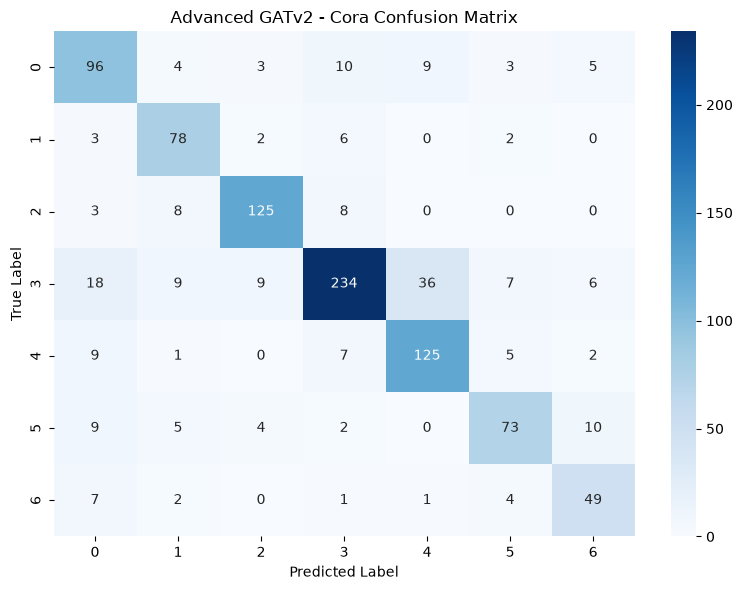

In [28]:
cm = confusion_matrix(
    y_test,
    pred_test
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Advanced GATv2 - Cora Confusion Matrix")

plt.tight_layout()
plt.show()

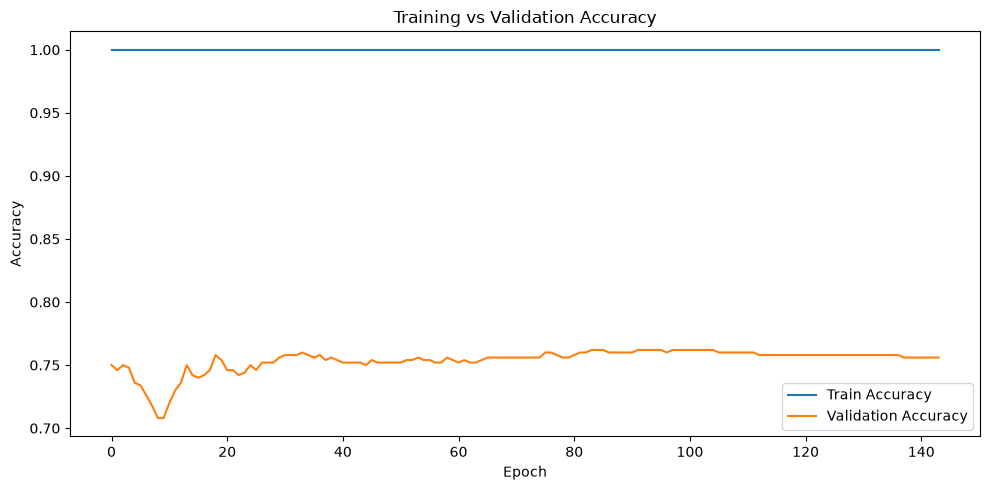

In [29]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    train_accs,
    label="Train Accuracy"
)

ax.plot(
    val_accs,
    label="Validation Accuracy"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Validation Accuracy")

ax.legend()

plt.tight_layout()
plt.show()

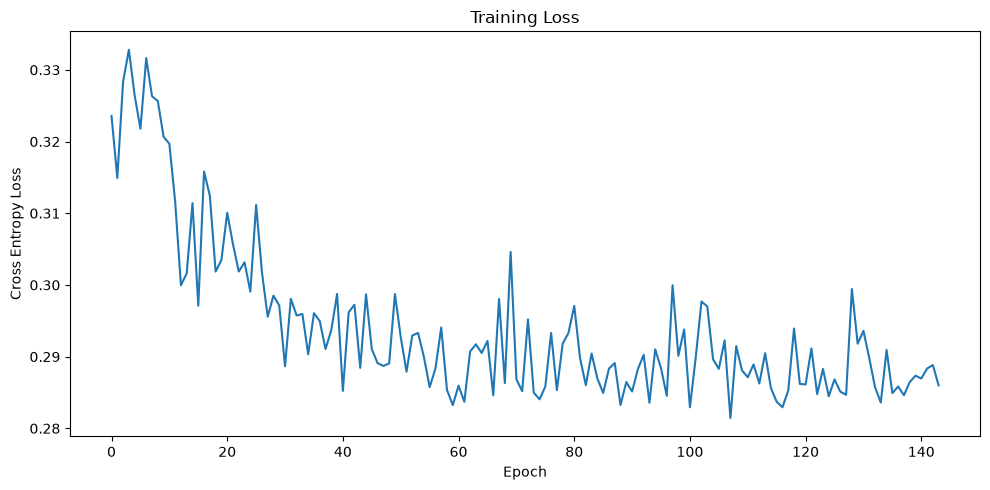

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Training Loss")

plt.tight_layout()
plt.show()

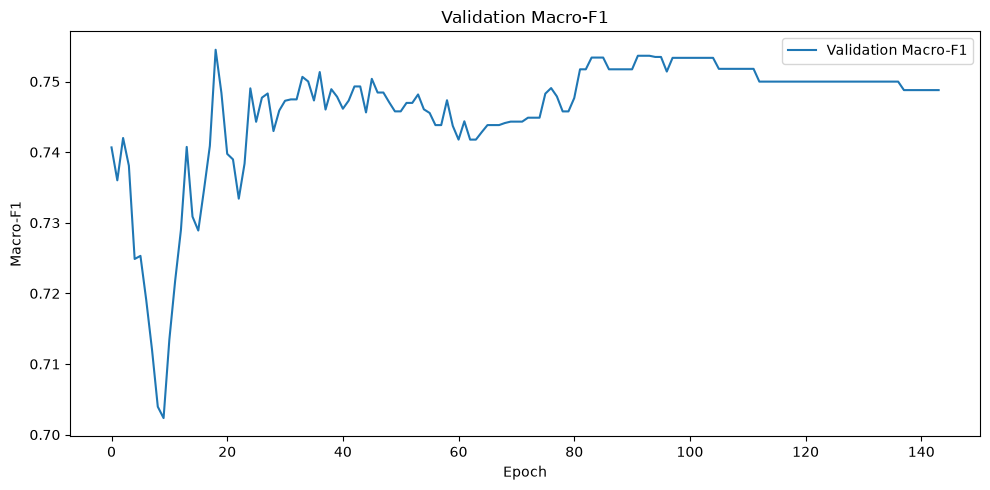

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    val_f1s,
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title("Validation Macro-F1")

plt.legend()

plt.tight_layout()
plt.show()


In [34]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": INPUT_DIM,
        "hidden_dim": HIDDEN_DIM,
        "num_classes": NUM_CLASSES,
        "num_layers": NUM_LAYERS,
        "heads": HEADS
    },
    "../artifacts/models/advanced_cora_gatv2.pt"
)

print("Model saved successfully.")

Model saved successfully.


In [35]:
import torch
import onnx
import onnxruntime as ort

model.eval()

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "../artifacts/models/advanced_cora_gatv2.onnx"

torch.onnx.export(
    model,
    (x_dummy, edge_index_dummy),
    onnx_file_path,

    # Store trained weights inside ONNX file
    export_params=True,

    # ONNX opset
    opset_version=18,

    # Optimize constant expressions
    do_constant_folding=True,

    # Input names
    input_names=[
        "node_features",
        "edge_index"
    ],

    # Output names
    output_names=[
        "logits"
    ],

    # Dynamic graph size
    dynamic_axes={
        "node_features": {
            0: "num_nodes"
        },

        "edge_index": {
            1: "num_edges"
        },

        "logits": {
            0: "num_nodes"
        }
    }
)

print(f"ONNX model exported to: {onnx_file_path}")

C:\Users\sumit\AppData\Local\Temp\ipykernel_24404\1760184887.py:12: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `AdvancedCoraGAT([...]` with `torch.export.export(..., strict=False)`...


W0911 20:49:13.686000 24404 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `AdvancedCoraGAT([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Users\sumit\AppData\Local\Programs\Python\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model exported to: ../artifacts/models/advanced_cora_gatv2.onnx
